# Step 6: Neural Network & PyTorch

## tensor.py

In [ ]:
import torch

x = torch.tensor(5.0, requires_grad=True)
y = 3 * x ** 2
print(y)

y.backward()    # 逆伝播を計算   
print(x.grad)   # dy/dx = 6 * x = 30 となるはず

tensor(75., grad_fn=<MulBackward0>)
tensor(30.)


## Rosenbrock function

$$
y = 100(x_1-x_0^2)^2 + (x_0-1)^2
$$

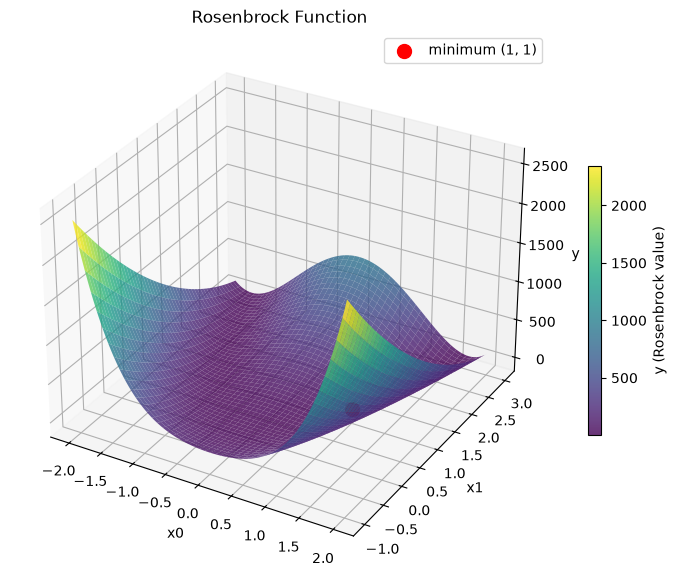

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x0 = np.linspace(-2, 2, 200)
x1 = np.linspace(-1, 3, 200)
x0, x1 = np.meshgrid(x0, x1)
y = 100 * (x1 - x0**2)**2 + (x0 - 1)**2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x0, x1, y, cmap='viridis', alpha=0.8)
fig.colorbar(surf, ax=ax, shrink=0.5, label='y (Rosenbrock value)')

ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('Rosenbrock Function')
plt.show()

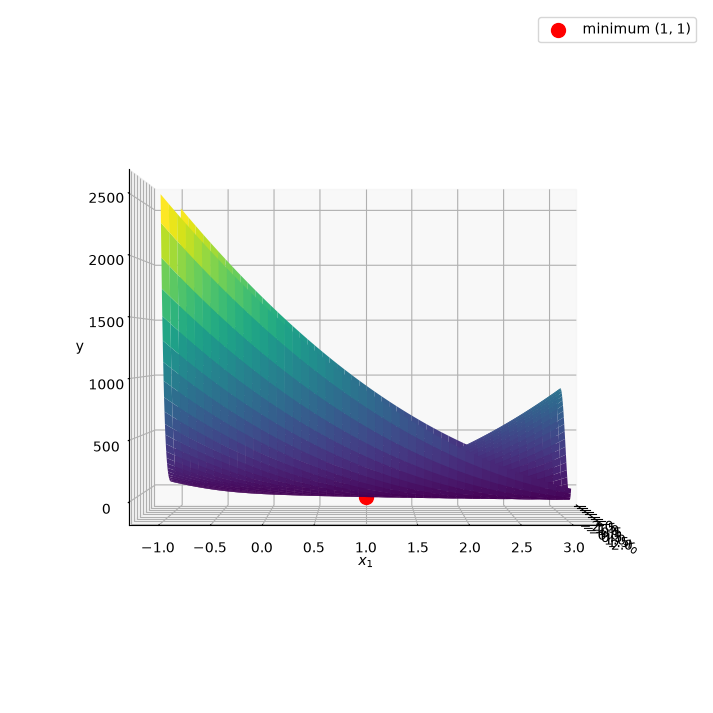

In [45]:
from matplotlib.colors import LogNorm
import numpy as np

_x0 = np.linspace(-2, 2, 200)
_x1 = np.linspace(-1, 3, 200)
_x0, _x1 = np.meshgrid(_x0, _x1)
_y = 100 * (_x1 - _x0**2)**2 + (_x0 - 1)**2

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(_x0, _x1, _y, cmap='viridis') # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.view_init(elev=0, azim=0) # 表示アングル
plt.show()

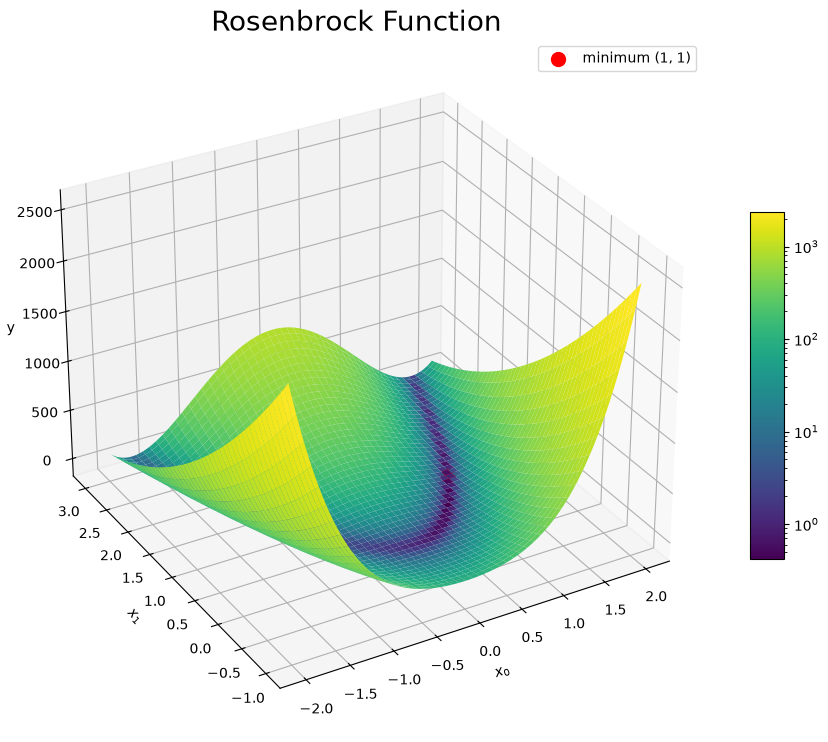

In [46]:
import numpy as np
from matplotlib.colors import LogNorm

_x0 = np.linspace(-2, 2, 200)
_x1 = np.linspace(-1, 3, 200)
_x0, _x1 = np.meshgrid(_x0, _x1)
_y = 100 * (_x1 - _x0**2)**2 + (_x0 - 1)**2

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(_x0, _x1, _y, cmap='viridis', norm=LogNorm()) # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.set_title('Rosenbrock Function', fontsize=20) # タイトル
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=30, azim=240) # 表示アングル
plt.show()

## gradient.py

In [47]:
import torch

def rosenbrock(x0, x1):
    y = 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2
    return y

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

y = rosenbrock(x0, x1)
y.backward()
print(x0.grad, x1.grad)

tensor(-2.) tensor(400.)


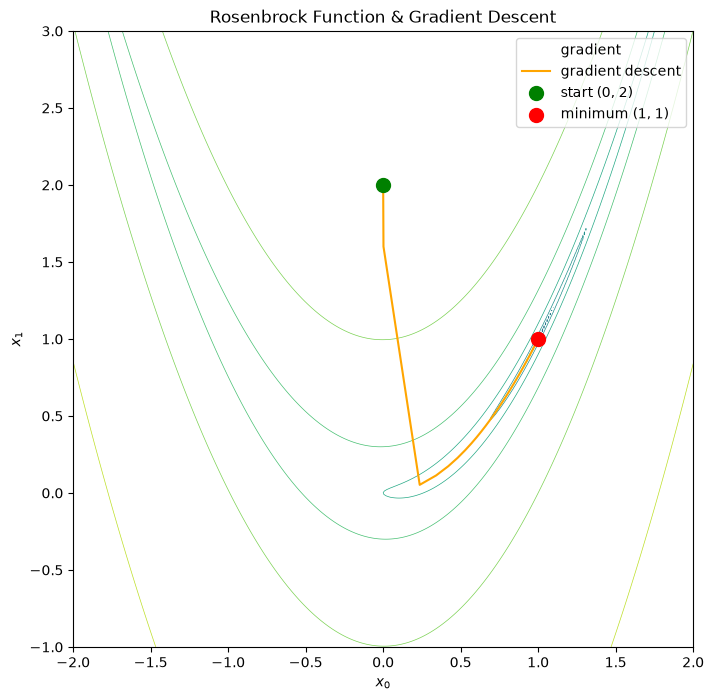

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

# 等高線用グリッド
_x0 = np.linspace(-2, 2, 400)
_x1 = np.linspace(-1, 3, 400)
_x0g, _x1g = np.meshgrid(_x0, _x1)
_y = 100 * (_x1g - _x0g**2)**2 + (_x0g - 1)**2

# 勾配降下軌跡を記録
def rosenbrock(x0, x1):
    return 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)
lr = 0.001
iters = 10000

path = [(x0.item(), x1.item())]
for i in range(iters):
    y = rosenbrock(x0, x1)
    y.backward()
    x0.data -= lr * x0.grad.data
    x1.data -= lr * x1.grad.data
    x0.grad.zero_()
    x1.grad.zero_()
    if i % 100 == 0:
        path.append((x0.item(), x1.item()))

path = np.array(path)

# 勾配ベクトル用グリッド（解析的勾配）
_gx0 = np.linspace(-2, 2, 15)
_gx1 = np.linspace(-1, 3, 15)
_ggx0, _ggx1 = np.meshgrid(_gx0, _gx1)
_dfdx0 = -400 * _ggx0 * (_ggx1 - _ggx0**2) + 2 * (_ggx0 - 1)
_dfdx1 =  200 * (_ggx1 - _ggx0**2)
_norm = np.sqrt(_dfdx0**2 + _dfdx1**2) + 1e-8

# プロット
fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contour(_x0g, _x1g, _y, levels=30, norm=LogNorm(), cmap='viridis', linewidths=0.5)
ax.quiver(_ggx0, _ggx1, _dfdx0/_norm, _dfdx1/_norm,
          alpha=0.4, scale=30, width=0.003, color='white', label='gradient')
ax.plot(path[:, 0], path[:, 1], color='orange', linewidth=1.5, label='gradient descent')
ax.scatter(*path[0], color='green', s=100, zorder=5, label='start (0, 2)')
ax.scatter(1, 1, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Rosenbrock Function & Gradient Descent')
ax.legend()
plt.show()

In [48]:
lr = 0.001  # learning rate
iters = 10000  # iteration count

for i in range(iters):
    if i % 1000 == 0:
        print(x0.item(), x1.item())

    y = rosenbrock(x0, x1)

    y.backward()

    x0.data -= lr * x0.grad.data
    x1.data -= lr * x1.grad.data

    x0.grad.zero_()
    x1.grad.zero_()

print(x0.item(), x1.item())

0.0 2.0
0.6815015077590942 0.46292299032211304
0.8253857493400574 0.6804871559143066
0.8942827582359314 0.7992911338806152
0.9331904053688049 0.8705660700798035
0.9568046927452087 0.9152978658676147
0.9716982245445251 0.9440822601318359
0.9813036918640137 0.9628812670707703
0.98758465051651 0.9752733111381531
0.9917276501655579 0.983490526676178
0.9944759607315063 0.9889602065086365


## regression.py

41.89796447753906
0.22483211755752563
0.0925208106637001
0.0888015553355217
0.08627457916736603
0.08435674756765366
0.0829005315899849
0.0817948430776596
0.08095530420541763
0.08031783998012543
0.07987643033266068
====
W = 2.2863590717315674
b = 5.3144850730896


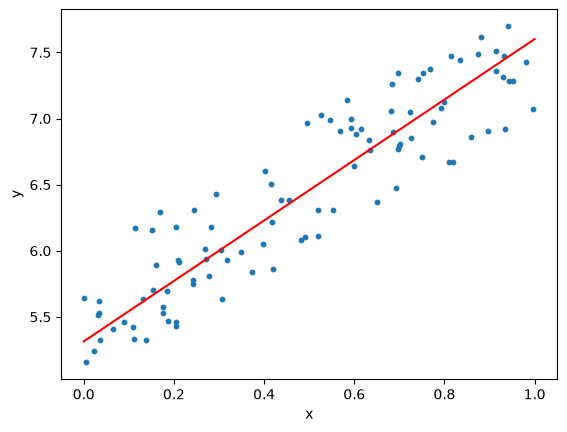

In [40]:
import torch


torch.manual_seed(0)
x = torch.rand(100, 1)
y = 5 + 2 * x + torch.rand(100, 1)

W = torch.zeros((1, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def predict(x):
    y = x @ W + b
    return y

def mean_squared_error(x0, x1):
    diff = x0 - x1
    N = len(diff)
    return torch.sum(diff ** 2) / N

lr = 0.1
iters = 100

for i in range(iters):
    y_hat = predict(x)
    loss = mean_squared_error(y, y_hat)

    loss.backward()

    W.data -= lr * W.grad.data
    b.data -= lr * b.grad.data

    W.grad.zero_()
    b.grad.zero_()

    if i % 10 == 0: # print every 10 iterations
        print(loss.item())

print(loss.item())
print('====')
print('W =', W.item())
print('b =', b.item())


# plot
import matplotlib.pyplot as plt
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
x = torch.tensor([[0.0], [1.0]])
y = W.detach().numpy() * x.detach().numpy() + b.detach().numpy()
plt.plot(x, y, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## neuralnet.py

0.7643452286720276
0.23656319081783295
0.2322607785463333
0.22441406548023224
0.21026146411895752
0.17957882583141327
0.11798450350761414
0.08470459282398224
0.08017464727163315
0.07966045290231705
0.07946839183568954


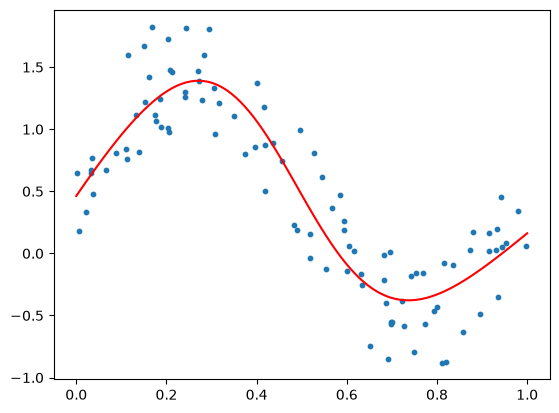

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F


torch.manual_seed(0)
x = torch.rand(100, 1)
y = torch.sin(2 * torch.pi * x) + torch.rand(100, 1)

# model
class Model(nn.Module):
    def __init__(self, input_size=1, hidden_size= 10, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        y = self.linear1(x)
        y = F.sigmoid(y)
        y = self.linear2(y)
        return y


lr = 0.2
iters = 10000

model = Model()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

for i in range(iters):
    y_pred = model(x)
    loss = F.mse_loss(y, y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 1000 == 0:
        print(loss.item())

print(loss.item())

# plot
import matplotlib.pyplot as plt
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
x = torch.linspace(0, 1, 100).reshape(-1, 1)
y = model(x).detach().numpy()
plt.plot(x, y, color='red')
plt.show()

## vision.py

size: 60000
type: <class 'PIL.Image.Image'>
label: 5


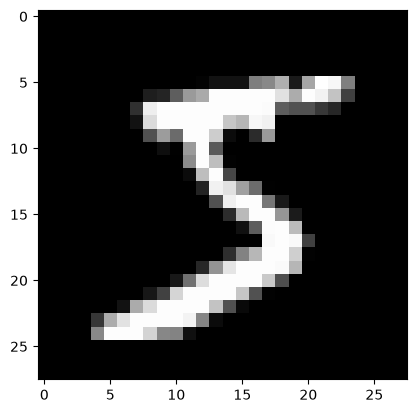

type: <class 'torch.Tensor'>
shape: torch.Size([1, 28, 28])
x shape: torch.Size([32, 1, 28, 28])
label shape: torch.Size([32])


In [42]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


## ==== MNIST ====
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=None,
    download=True
)

x, label = dataset[0]

print('size:', len(dataset))  # size: 60000
print('type:', type(x))  # type: <class 'PIL.Image.Image'>
print('label:', label)  # label: 5

plt.imshow(x, cmap='gray')
plt.show()


# ==== preprocess ====
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

x, label = dataset[0]
print('type:', type(x))  # type: <class 'torch.Tensor'>
print('shape:', x.shape)  # shape: torch.Size([1, 28, 28])


# ==== DataLoader ====
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True)

for x, label in dataloader:
    print('x shape:', x.shape)  # shape: torch.Size([32, 1, 28, 28])
    print('label shape:', label.shape)  # shape: torch.Size([32])
    break